# Belgian Real-Estate — Data Analysis

**BeCode project — data cleaning, exploration and analysis.**

This notebook turns the raw scraped dataset into clean, analysable data and answers two questions.
The logic is organised in **three classes**, one responsibility each:

- **`DataCleaner`** — loads the raw CSV and returns a cleaned DataFrame.
- **`DataVisualizer`** — general overview charts (dashboard + price map).
- **`MeetingAnswers`** — the two meeting questions, each with a chart:
  - **Q1.** Which variables would you delete, and why?
  - **Q2.** Which five variables most influence the price, and why?

## 1. Setup

Imports, plotting style, and the path to the dataset.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

%matplotlib inline
sns.set_theme(style="whitegrid")

# Put properties_cleaned.csv next to this notebook, or edit the path below.
CSV_PATH = "properties_cleaned.csv"

## 2. Data cleaning

`DataCleaner` applies an 8-step pipeline:

1. **Drop useless columns** — `price_type` (constant) and `property_id` (duplicate of `property_url`).
2. **Normalise the city** — `la-roche-en-ardenne` → `La Roche En Ardenne`.
3. **Standardise the building state** — merge synonyms (`To be renovated` → `To renovate`) + *ordered* category.
4. **Ordered categories** for EPC and kitchen.
5. **Booleans → nullable `Int8`** (with an explicit assumption on the `has_*` flags).
6. **Fix swapped coordinates** — only when the swap is *confirmed by the postal code* (an independent source).
7. **Flag suspect values** — `price_suspect`, `area_suspect`, `year_suspect` (without modifying them).
8. **Derived feature** — `price_per_m2`.

> Principle: auto-correct only what is **indisputable** (geographic swaps verified against the postal code),
> and merely **flag** what needs judgment (price/area/year outliers).

In [5]:
class DataCleaner:
    """Loads the raw scraper CSV and produces a cleaned DataFrame.

    All cleaning knowledge (category orders, synonyms, geographic bounds,
    plausibility thresholds) lives here as class attributes, so there is a
    single place to update.
    """

    BOOL_COLS = [
        "furnished", "has_garage", "has_garden", "has_terrace",
        "has_elevator", "is_nearby_city_prestigious",
    ]
    PRESENCE_FLAGS = ["has_garage", "has_garden", "has_terrace", "has_elevator", "furnished"]

    EPC_ORDER = ["A++", "A+", "A", "B+", "B", "C", "D", "E+", "E", "F", "G"]
    STATE_ORDER = [
        "New", "Excellent", "Fully renovated", "Normal",
        "To renovate", "To restore", "Under construction", "To demolish",
    ]
    STATE_SYNONYMS = {"To be renovated": "To renovate"}
    KITCHEN_ORDER = ["Not equipped", "Partially equipped", "Fully equipped", "Super equipped"]

    # Geographic bounds of Belgium + max distance to accept a coordinate swap.
    BE_LAT = (49, 52)
    BE_LON = (2, 7)
    SWAP_MAX_KM = 25

    # Bedroom/area plausibility FLAG (review, not deletion). No threshold: every
    # listing is checked against a loose per-bedroom minimum.
    MIN_M2_PER_BEDROOM_SMALL = 9
    MIN_COMMON_AREA_M2 = 15

    # Hard floors for DELETION — physically impossible values only.
    HARD_MIN_PRICE = 10_000        # no real residential sale below this
    HARD_MIN_AREA = 10             # m², below this a dwelling is impossible
    HARD_MIN_M2_PER_BEDROOM = 5    # absolute floor: a bedroom needs at least this

    def __init__(self, path):
        """Store the path and load the raw CSV (kept untouched in self.raw)."""
        self.path = path
        self.raw = pd.read_csv(path)   # untouched copy, useful for the Q1 audit
        self.df = None                 # filled by clean()

    # ----- geographic helpers -----

    @staticmethod
    def _haversine(lat1, lon1, lat2, lon2):
        """Great-circle distance in km between two points (decimal degrees)."""
        R = 6371
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
        return 2 * R * np.arcsin(np.sqrt(a))

    def _postal_centroids(self, df):
        """Median lat/lon per postal code, from rows already inside Belgium.

        Independent ground truth (postal code comes from the URL) used to
        validate coordinate swaps.
        """
        valid = df["latitude"].between(*self.BE_LAT) & df["longitude"].between(*self.BE_LON)
        return df[valid].groupby("postal_code")[["latitude", "longitude"]].median()

    def _fix_swapped_coordinates(self, df):
        """Swap lat/lon only when it brings the point near its postal centroid.

        Rows where the swap is not confirmed are left untouched and flagged
        coord_suspect. Adds coord_swapped and coord_suspect.
        """
        cent = self._postal_centroids(df)
        candidate = ~(df["latitude"].between(*self.BE_LAT) & df["longitude"].between(*self.BE_LON))

        df["coord_swapped"] = False
        df["coord_suspect"] = False

        for i in df.index[candidate]:
            pc = df.at[i, "postal_code"]
            lat, lon = df.at[i, "latitude"], df.at[i, "longitude"]
            if pd.isna(lat) or pc not in cent.index:
                df.at[i, "coord_suspect"] = True
                continue
            clat, clon = cent.loc[pc, "latitude"], cent.loc[pc, "longitude"]
            if self._haversine(lon, lat, clat, clon) < self.SWAP_MAX_KM:
                df.at[i, "latitude"], df.at[i, "longitude"] = lon, lat
                df.at[i, "coord_swapped"] = True
            else:
                df.at[i, "coord_suspect"] = True
        return df

    # ----- plausibility flag + deletion -----

    def _flag_suspect_bedroom_count(self, df):
        """Flag listings whose living area is too small for their bedroom count.

        No threshold: every listing is checked against a loose per-bedroom
        minimum (MIN_M2_PER_BEDROOM_SMALL each + MIN_COMMON_AREA_M2). This is a
        REVIEW flag, not a deletion rule — small but legitimate studios may be
        flagged. Adds bedroom_suspect (bool); does not modify any value.
        """
        min_required_area = (
            df["bedrooms"] * self.MIN_M2_PER_BEDROOM_SMALL + self.MIN_COMMON_AREA_M2
        )
        df["bedroom_suspect"] = df["living_area_m2"] < min_required_area
        return df

    def _drop_impossible_rows(self, df):
        """Delete physically impossible rows (real errors, not judgment calls).

        Removes listings whose price or area cannot match a real dwelling: price
        below HARD_MIN_PRICE, living area below HARD_MIN_AREA, or living area too
        small for the bedroom count. Prints how many rows were removed.
        (NaN comparisons return False, so rows with missing values are NOT dropped.)
        """
        before = len(df)
        impossible = (
            (df["price"] < self.HARD_MIN_PRICE)
            | (df["living_area_m2"] < self.HARD_MIN_AREA)
            | (df["living_area_m2"] < df["bedrooms"] * self.HARD_MIN_M2_PER_BEDROOM)
        )
        df = df[~impossible].copy()
        print(f"Dropped {before - len(df)} impossible rows "
              f"(price < {self.HARD_MIN_PRICE} EUR, area < {self.HARD_MIN_AREA} m2, "
              f"or < {self.HARD_MIN_M2_PER_BEDROOM} m2/bedroom)")
        return df

    # ----- main entry -----

    def clean(self):
        """Run the full cleaning pipeline and return the cleaned DataFrame."""
        df = self.raw.copy()

        # 1) Drop useless columns (constant + duplicate). See Q1.
        df = df.drop(columns=[c for c in ["price_type", "property_id"] if c in df.columns])

        # 2) Normalise the city slug: "la-roche-en-ardenne" -> "La Roche En Ardenne".
        df["city"] = df["city"].str.replace("-", " ", regex=False).str.title()

        # 3) Building state: merge synonyms + ordered category.
        df["state_of_the_building"] = df["state_of_the_building"].replace(self.STATE_SYNONYMS)
        df["state_of_the_building"] = pd.Categorical(
            df["state_of_the_building"], categories=self.STATE_ORDER, ordered=True
        )

        # 4) EPC and kitchen as ordered categories (values outside the list -> NaN).
        df["epc_score"] = pd.Categorical(df["epc_score"], categories=self.EPC_ORDER, ordered=True)
        df["kitchen_equipped"] = pd.Categorical(
            df["kitchen_equipped"], categories=self.KITCHEN_ORDER, ordered=True
        )

        # 5) Booleans -> nullable Int8. NOTE: has_* only recorded "Yes" (1), so a
        #    NaN means "not mentioned"; NaN->0 is a modelling CHOICE.
        for col in self.BOOL_COLS:
            if col in self.PRESENCE_FLAGS:
                df[col] = df[col].fillna(0)
            df[col] = df[col].astype("Int8")

        # 6) Fix swapped coordinates (validated against the postal code).
        df = self._fix_swapped_coordinates(df)

        # 7) Flag (without modifying) suspect values for later investigation.
        df["price_suspect"] = (df["price"] < 20_000) | (df["price"] > 10_000_000)
        df["area_suspect"]  = (df["living_area_m2"] < 10) | (df["living_area_m2"] > 2000)
        df["year_suspect"]  = (df["building_year"] < 1700) | (df["building_year"] > 2030)
        df = self._flag_suspect_bedroom_count(df)

        # 8) Derived feature: price per m².
        df["price_per_m2"] = (df["price"] / df["living_area_m2"]).round(0)

        # 9) Delete physically impossible rows (logged). The flags above keep the
        #    "suspect-but-plausible" cases for review; here we only remove errors.
        df = self._drop_impossible_rows(df)
        df = df.reset_index(drop=True)   # tidy index after the deletion

        self.df = df
        return df

Instantiate the cleaner and run the pipeline:

In [6]:
cleaner = DataCleaner(CSV_PATH)
df = cleaner.clean()
print(f"Cleaned: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Coordinates swapped: {int(df['coord_swapped'].sum())} | suspect: {int(df['coord_suspect'].sum())}")
df.head()

Dropped 12 impossible rows (price < 10000 EUR, area < 10 m2, or < 5 m2/bedroom)
Cleaned: 12679 rows x 39 columns
Coordinates swapped: 47 | suspect: 3


,property_type,property_subtype,price,living_area_m2,bedrooms,bathrooms,address,postal_code,city,latitude,...,is_nearby_city_prestigious,floor_number,property_url,coord_swapped,coord_suspect,price_suspect,area_suspect,year_suspect,bedroom_suspect,price_per_m2
0,House,residence,550000.0,250.0,4.0,1.0,Rue des Nonnes 32A,4400,Flemalle,50.601373,...,0,NaN,https://immovlan.be/en/detail/residence/for-sa...,False,False,False,False,False,False,2200.0
1,Apartment,apartment,200000.0,57.0,1.0,1.0,Avenue Louise 32A,1050,Elsene,50.834517,...,0,2.0,https://immovlan.be/en/detail/apartment/for-sa...,False,False,False,False,False,False,3509.0
2,Apartment,duplex,189000.0,115.0,1.0,1.0,NaN,7500,Tournai,50.605606,...,0,NaN,https://immovlan.be/en/detail/duplex/for-sale/...,False,False,False,False,False,False,1643.0
3,House,residence,549000.0,399.0,3.0,3.0,Kerkstraat 20 + 20/1,3941,Eksel,51.152694,...,0,NaN,https://immovlan.be/en/detail/residence/for-sa...,False,False,False,False,False,False,1376.0
4,House,residence,330000.0,99.0,3.0,1.0,Quartier de Lohan 1,6980,La Roche En Ardenne,50.180368,...,0,NaN,https://immovlan.be/en/detail/residence/for-sa...,False,False,False,False,False,False,3333.0


We did not delete any row — outliers are only **flagged**, ready to be investigated later:

In [7]:
# Nothing was deleted — suspect values are only flagged, ready to investigate.
df[["price_suspect", "area_suspect", "year_suspect", "coord_suspect"]].sum()

price_suspect     4
area_suspect     12
year_suspect     14
coord_suspect     3
dtype: int64

## 3. General visualization

An overview dashboard and a geographic price map.

In [8]:
class DataVisualizer:
    """General overview charts for the cleaned dataset (rendered inline)."""

    def __init__(self, df):
        self.df = df

    def dashboard(self):
        """2x3 overview: prices, regions, types, area, EPC, provinces."""
        df = self.df
        fig, axes = plt.subplots(2, 3, figsize=(20, 11))
        fig.suptitle("Real-estate dataset — overview", fontsize=18, fontweight="bold")

        sns.histplot(df["price"].dropna(), bins=60, log_scale=True, ax=axes[0, 0], color="#4C72B0")
        axes[0, 0].set_title("Price distribution (log scale)")
        axes[0, 0].set_xlabel("Price (EUR)")

        sns.boxplot(data=df, x="region", y="price", ax=axes[0, 1], showfliers=False)
        axes[0, 1].set_title("Price by region")
        axes[0, 1].set_ylabel("Price (EUR)")

        df["property_type"].value_counts().plot(kind="bar", ax=axes[0, 2], color=["#55A868", "#C44E52"])
        axes[0, 2].set_title("Property type")
        axes[0, 2].set_xlabel("")
        axes[0, 2].tick_params(axis="x", rotation=0)

        sample = df.dropna(subset=["living_area_m2", "price"]).sample(
            min(3000, df["price"].notna().sum()), random_state=0
        )
        sns.scatterplot(data=sample, x="living_area_m2", y="price", hue="property_type",
                        alpha=0.4, s=18, ax=axes[1, 0])
        axes[1, 0].set_title("Living area vs price")
        axes[1, 0].set_xlabel("Living area (m2)")
        axes[1, 0].set_ylabel("Price (EUR)")

        order = [c for c in DataCleaner.EPC_ORDER if c in df["epc_score"].cat.categories]
        sns.countplot(data=df, x="epc_score", order=order, ax=axes[1, 1], color="#8172B3")
        axes[1, 1].set_title("Energy classes (EPC)")
        axes[1, 1].set_xlabel("EPC class")

        df["province"].value_counts().plot(kind="barh", ax=axes[1, 2], color="#CCB974")
        axes[1, 2].set_title("Number of listings per province")
        axes[1, 2].invert_yaxis()

        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

    def price_map(self):
        """Geographic scatter of price per m2 across Belgium."""
        geo = self.df.dropna(subset=["latitude", "longitude", "price_per_m2"])
        lo, hi = geo["price_per_m2"].quantile([0.01, 0.99])   # clip for colour scale
        geo = geo[(geo["price_per_m2"] >= lo) & (geo["price_per_m2"] <= hi)]

        plt.figure(figsize=(11, 11))
        sc = plt.scatter(geo["longitude"], geo["latitude"], c=geo["price_per_m2"],
                         cmap="viridis", s=6, alpha=0.6)
        plt.colorbar(sc, label="Price per m2 (EUR)")
        plt.title("Price per m2 map (Belgium)", fontsize=15, fontweight="bold")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.gca().set_aspect("equal", adjustable="datalim")
        plt.show()

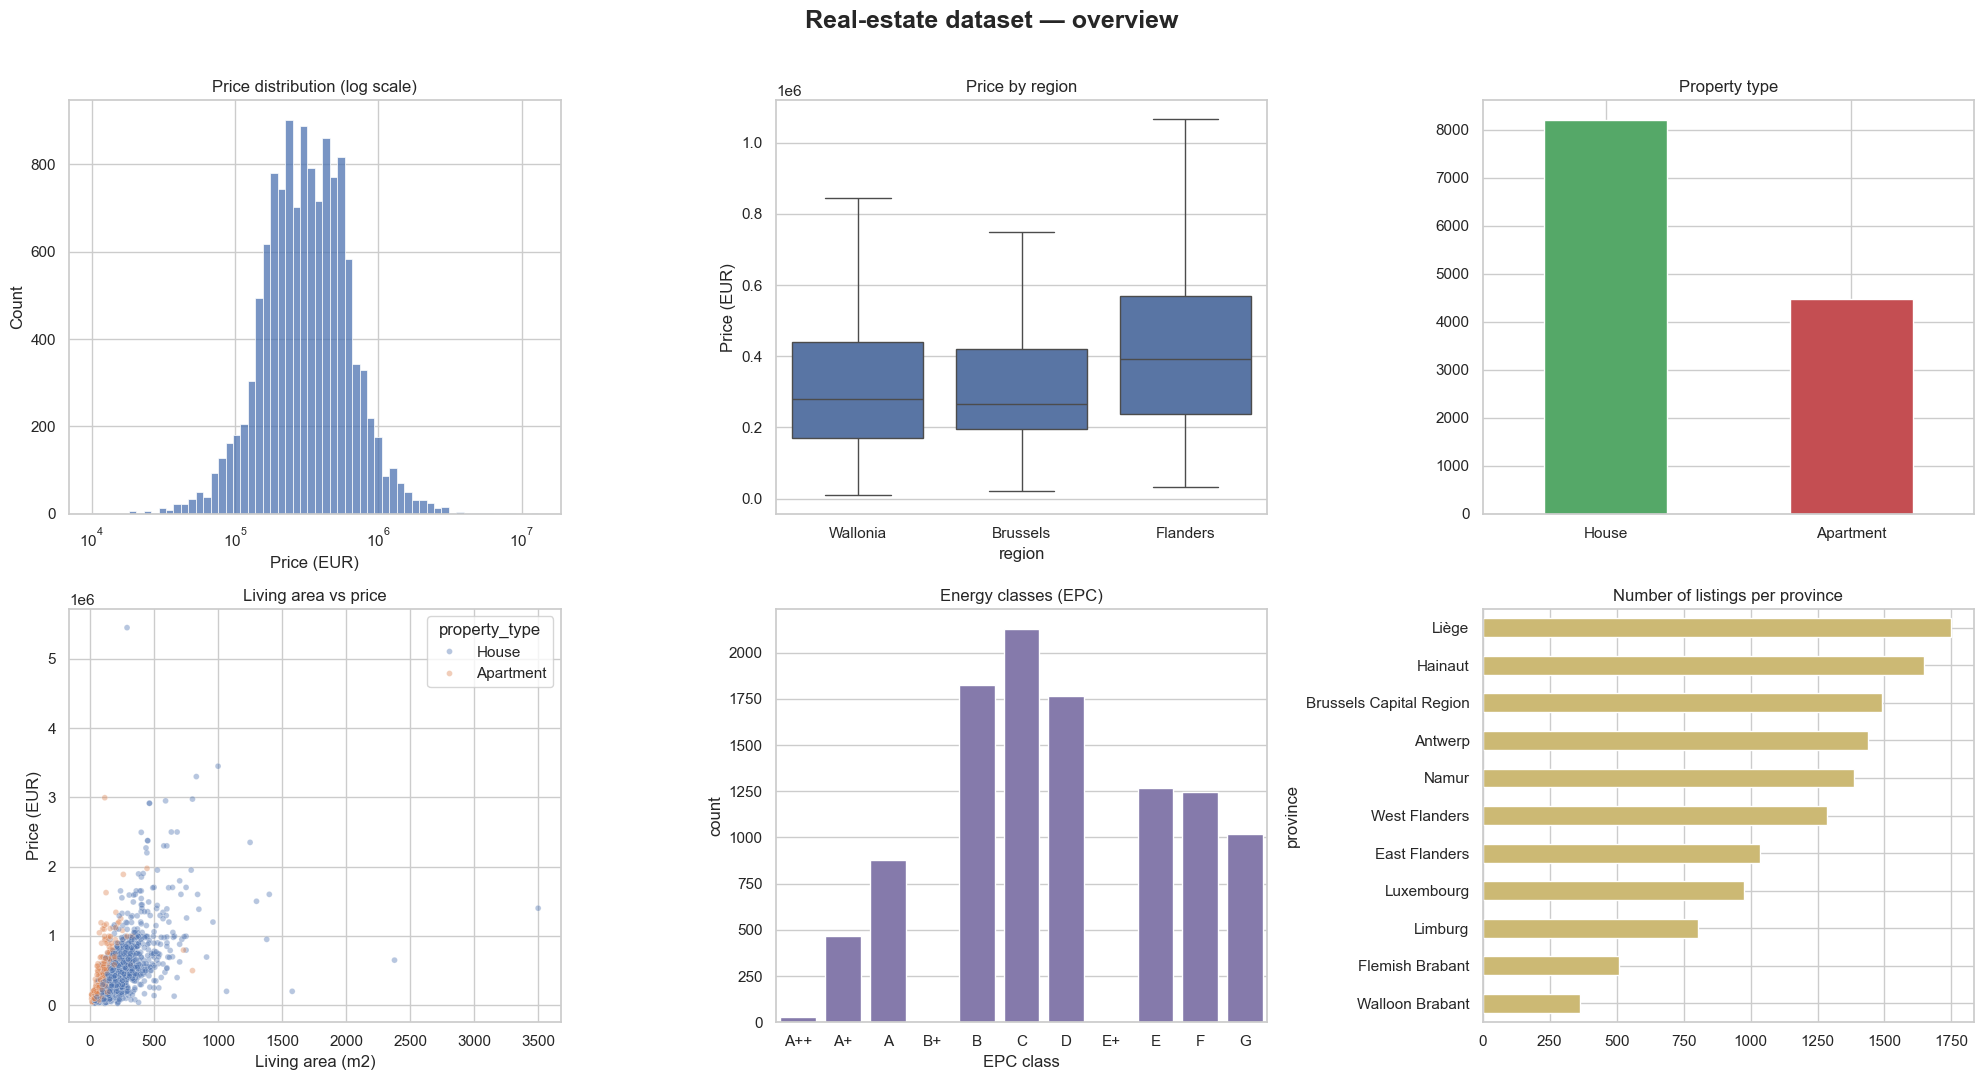

In [9]:
viz = DataVisualizer(df)
viz.dashboard()

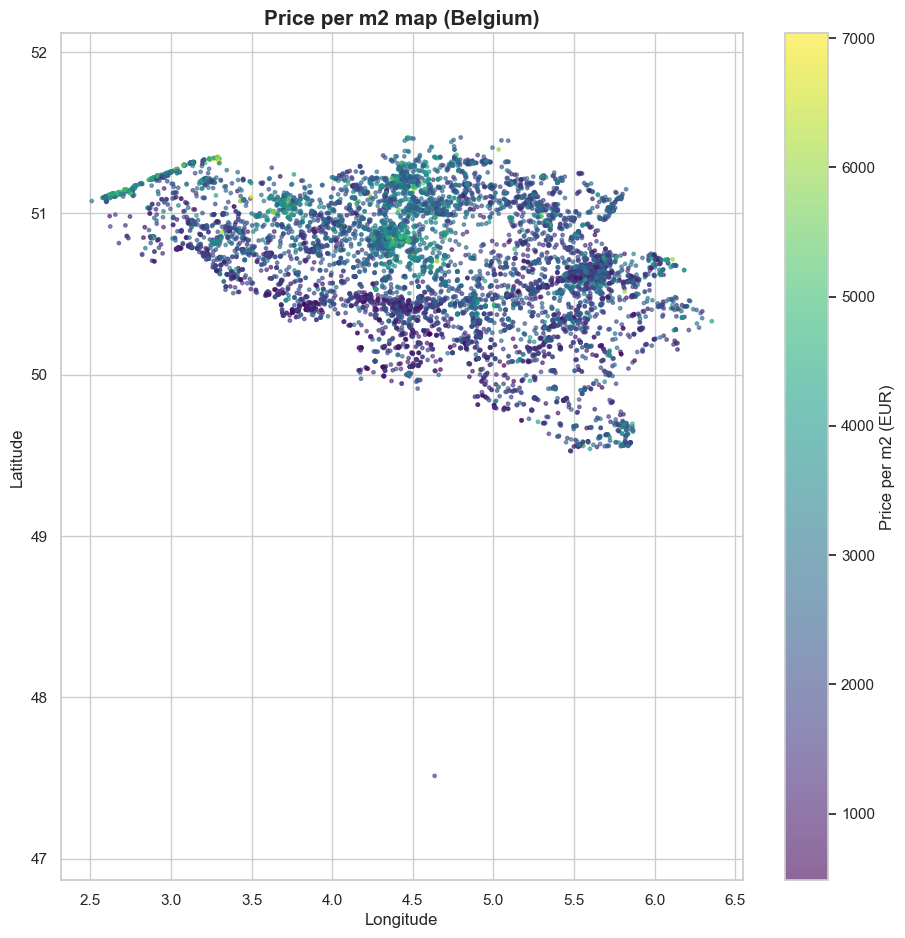

In [10]:
viz.price_map()

## 4. Meeting questions

In [11]:
class MeetingAnswers:
    """
    Q1 uses the RAW data (to justify deletions on the original columns);
    Q2 uses the CLEANED data (to rank what drives the price).
    """

    NON_FEATURES = [
        "price", "price_per_m2",                            # target + leakage
        "property_url", "address", "city", "postal_code",  # identifiers / high-cardinality
        "coord_swapped", "coord_suspect",
        "price_suspect", "area_suspect", "year_suspect",
    ]

    def __init__(self, raw_df, clean_df):
        self.raw = raw_df
        self.df = clean_df

    def which_columns_to_drop(self):
        """Q1 — identify columns to delete and visualise why.

        Reasons detected on the RAW data: constant (1 value), duplicate
        (identical to another column), or mostly empty (>75% missing).
        """
        raw = self.raw
        reasons = []

        for c in raw.columns:                                   # constant columns
            if raw[c].nunique(dropna=False) <= 1:
                reasons.append((c, "constant (1 unique value)"))

        seen = {}                                               # duplicate columns
        for c in raw.columns:
            key = tuple(raw[c].fillna("∅").astype(str))
            if key in seen:
                reasons.append((c, f"duplicate of '{seen[key]}'"))
            else:
                seen[key] = c

        miss = raw.isna().mean()                                # mostly-empty columns
        for c in miss[miss > 0.75].index:
            reasons.append((c, f"mostly empty ({miss[c]*100:.0f}% missing)"))

        report = pd.DataFrame(reasons, columns=["column", "reason"])

        fig, axes = plt.subplots(1, 2, figsize=(18, 9))
        fig.suptitle("Q1 — Which variables to delete, and why", fontsize=16, fontweight="bold")

        miss_sorted = (miss * 100).sort_values(ascending=True)
        colors = ["#C44E52" if v > 75 else "#4C72B0" for v in miss_sorted.values]
        miss_sorted.plot(kind="barh", ax=axes[0], color=colors)
        axes[0].axvline(75, color="#C44E52", linestyle="--", linewidth=1)
        axes[0].set_title("Missing values per column (red dashed = 75%)")
        axes[0].set_xlabel("% missing")

        nun = raw.nunique(dropna=False).sort_values()
        colors2 = ["#C44E52" if v <= 1 else "#55A868" for v in nun.values]
        nun.plot(kind="barh", ax=axes[1], color=colors2, logx=True)
        axes[1].set_title("Unique values per column (log scale; red = constant)")
        axes[1].set_xlabel("# unique values")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
        return report

    def _build_feature_matrix(self, data):
        """Encode features for a tree model: numeric as-is, categoricals as codes.

        NOTE: nominal categories are label-encoded for simplicity, which keeps
        ONE importance per variable — convenient to answer "which variables
        matter". A tree model handles this fine for ranking.
        """
        feats = [c for c in data.columns if c not in self.NON_FEATURES]
        X = pd.DataFrame(index=data.index)
        for c in feats:
            s = data[c]
            if isinstance(s.dtype, pd.CategoricalDtype) or s.dtype == object:
                X[c] = s.astype("category").cat.codes          # NaN -> -1
            else:
                X[c] = pd.to_numeric(s, errors="coerce")
        X = X.fillna(X.median(numeric_only=True))
        return X

    def top_price_drivers(self, n=5):
        """Q2 — rank the variables that most drive the price (RandomForest)."""
        df = self.df
        data = df[~df["price_suspect"] & ~df["area_suspect"]].dropna(subset=["price"])
        X = self._build_feature_matrix(data)
        y = data["price"]

        model = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=0)
        model.fit(X, y)

        importance = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
        top = importance.head(n)

        plt.figure(figsize=(11, 9))
        colors = ["#C44E52" if i < n else "#9aa0b3" for i in range(len(importance))]
        importance.sort_values().plot(kind="barh", color=colors[::-1])
        plt.title(f"Q2 — Variables driving the price (top {n} in red)", fontsize=15, fontweight="bold")
        plt.xlabel("Importance (RandomForest)")
        plt.tight_layout()
        plt.show()
        return top

### Q1 — Which variables would you delete, and why?

`which_columns_to_drop()` detects three deletion reasons on the **raw** data and plots them.

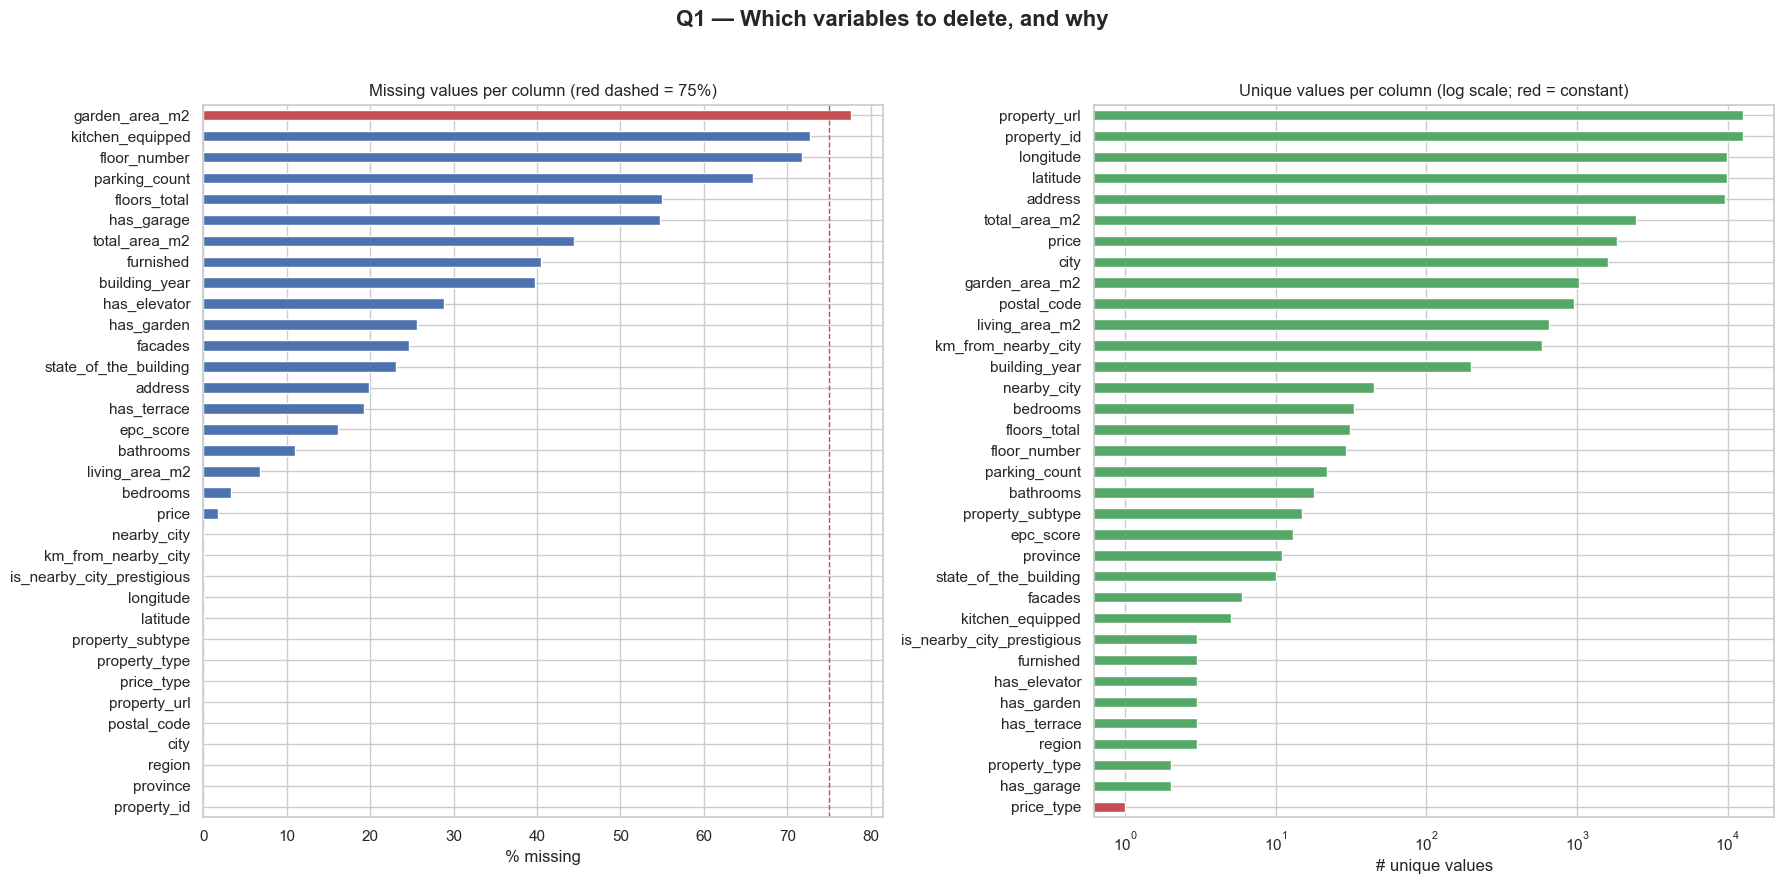

,column,reason
0,price_type,constant (1 unique value)
1,property_url,duplicate of 'property_id'
2,garden_area_m2,mostly empty (78% missing)


In [12]:
qa = MeetingAnswers(cleaner.raw, df)
report = qa.which_columns_to_drop()
report

**Answer.** Three deletions, three distinct reasons:

- **`price_type` — constant.** A single value (`sell`) → zero information (red bar, right panel).
- **`property_id` / `property_url` — duplicate.** Two identical columns → keep one, drop the other.
- **`garden_area_m2` — mostly empty (78% missing).** Weak, unreliable signal (red bar above the 75% line).
  `kitchen_equipped` (74%) and `floor_number` (71%) are borderline candidates of the same kind.

In short: we drop for **constant** (no info), **duplicate** (redundant), or **mostly empty** (weak signal).

### Q2 — The five variables that most influence the price

We train a **RandomForest** to predict `price` and read its feature importances, after excluding the
target, the leakage feature `price_per_m2`, identifiers, and the flagged suspect rows.

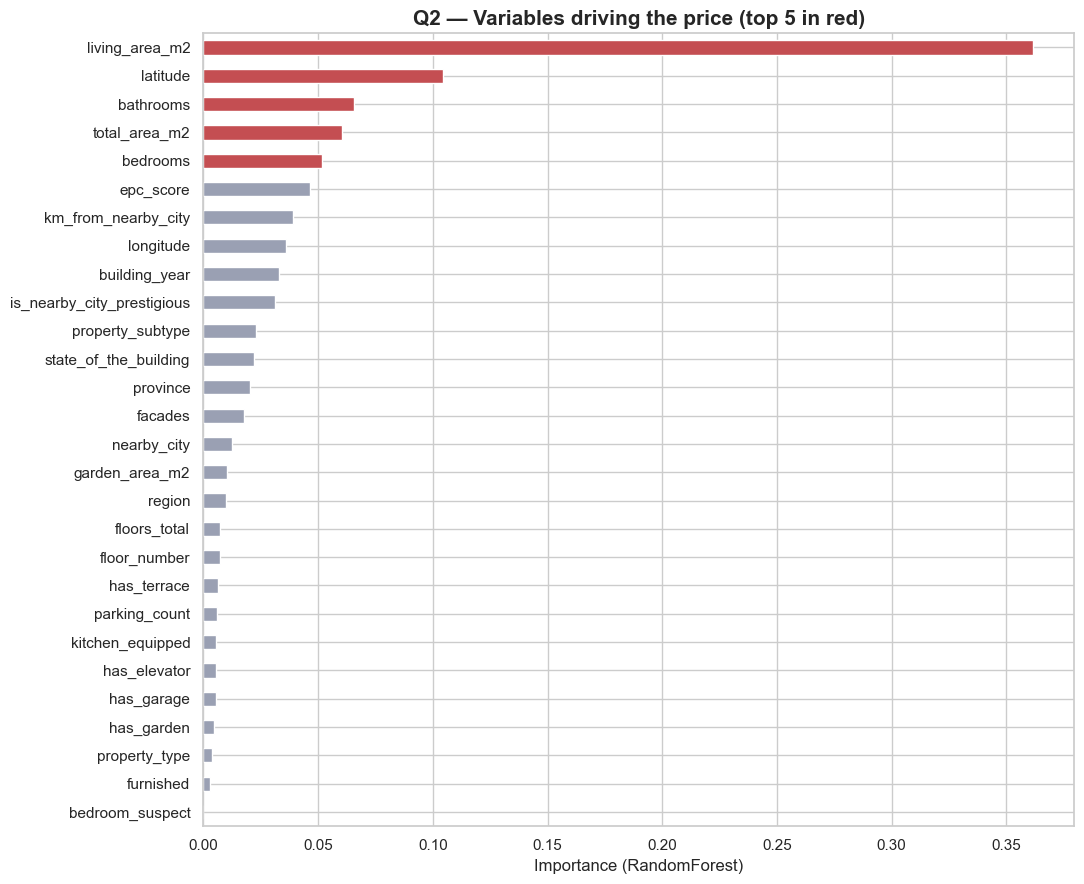

living_area_m2    0.361
latitude          0.105
bathrooms         0.066
total_area_m2     0.061
bedrooms          0.052
dtype: float64

In [13]:
top5 = qa.top_price_drivers(n=5)
top5.round(3)

**Answer — top 5 drivers:**

1. **`living_area_m2`** — by far the strongest: bigger living space = higher price.
2. **`latitude`** — a location proxy: the north/south gradient (Flanders vs Wallonia, urban vs rural).
3. **`total_area_m2`** — total surface (land + building): more space = more value.
4. **`bedrooms`** — number of bedrooms, a direct proxy for usable size.
5. **`epc_score`** — energy rating: an A property sells better than a G.

The story: **size + location + energy** explain most of the price. `bathrooms`, `km_from_nearby_city`
and `longitude` follow just behind, reinforcing the same two themes.

## 5. Summary

- The data is cleaned **non-destructively**: only indisputable errors are corrected, the rest is flagged.
- **Q1** — drop `price_type` (constant), one of `property_id`/`property_url` (duplicate), and very empty
  columns such as `garden_area_m2`.
- **Q2** — the price is driven mainly by **size** (`living_area_m2`, `total_area_m2`, `bedrooms`),
  **location** (`latitude`), and **energy class** (`epc_score`).
